# Notebook 10: Inertia Correction and Numerical Regularization

We have all the pieces: the IPM algorithm (notebook 7), the KKT matrix structure (notebook 8), and the BK-LDL$^T$ factorization (notebook 9). Now we handle the case where the KKT matrix has **wrong inertia** — which happens whenever the Lagrangian Hessian is indefinite or the constraint Jacobian is rank-deficient.

**Prerequisites:** Notebooks 7-9

**Learning objectives:**
- Understand when and why inertia goes wrong
- Implement the incremental inertia correction loop
- Implement iterative refinement for improved accuracy
- See a complete example where correction is essential

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvalsh, solve_triangular
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=8, suppress=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Re-use functions from previous notebooks

def assemble_kkt_matrix(H, Sigma, J, delta_w=0.0, delta_c=0.0):
    n = H.shape[0]
    Sigma_mat = np.diag(Sigma) if Sigma.ndim == 1 else Sigma
    m = J.shape[0] if J.ndim == 2 else 0
    K = np.zeros((n + m, n + m))
    K[:n, :n] = H + Sigma_mat + delta_w * np.eye(n)
    if m > 0:
        K[:n, n:] = J.T;  K[n:, :n] = J;  K[n:, n:] = -delta_c * np.eye(m)
    return K

def compute_inertia_eig(K, zero_tol=1e-10):
    """Compute inertia using numpy eigenvalues (reference implementation)."""
    eigs = eigvalsh(K)
    scale = max(abs(eigs).max(), 1.0)
    tol = zero_tol  # Use absolute tolerance!
    n_pos  = int(np.sum(eigs >  tol))
    n_neg  = int(np.sum(eigs < -tol))
    n_zero = int(np.sum(np.abs(eigs) <= tol))
    return n_pos, n_neg, n_zero, eigs

def check_inertia(K, n, m, zero_tol=1e-10):
    """
    Verify KKT matrix has correct inertia: (n positive, m negative, 0 zero).

    Parameters
    ----------
    K : array (n+m, n+m), KKT matrix
    n : int, number of primal variables (required positive eigenvalues)
    m : int, number of constraints (required negative eigenvalues)

    Returns
    -------
    is_correct : bool
    (n_pos, n_neg, n_zero) : tuple of ints
    """
    n_pos, n_neg, n_zero, _ = compute_inertia_eig(K, zero_tol)
    is_correct = (n_pos == n) and (n_neg == m) and (n_zero == 0)
    return is_correct, (n_pos, n_neg, n_zero)


print('Helper functions loaded.')

Helper functions loaded.


## 1. When Does Inertia Go Wrong?

Recall the KKT matrix:
$$K = \begin{pmatrix} H + \Sigma & J^T \\ J & 0 \end{pmatrix}$$

We need $n$ positive and $m$ negative eigenvalues. This fails when:

**Case 1: Indefinite Lagrangian Hessian**
The Lagrangian $\mathcal{L} = f + y^T g$ has Hessian $H = \nabla^2 f + \sum_j y_j \nabla^2 g_j$. If the constraint curvature terms $y_j \nabla^2 g_j$ are large and negative, $H$ can be very negative definite. The barrier $\Sigma$ adds positive terms but may not be large enough to overcome the negative curvature.

**Case 2: Rank-deficient constraint Jacobian**
If two constraints are (nearly) linearly dependent at the current point, $J$ loses rank. This means $K$ has a (nearly) zero eigenvalue, which "should" be negative.

**Case 3: Small $\mu$ near active bounds**
As $\mu \to 0$ and a bound becomes active, $\Sigma_{ii} \to \infty$ for that component. While this eventually makes $(H + \Sigma)$ positive definite, in the transition region the inertia can be temporarily wrong.

In [3]:
# Demonstrate each case of wrong inertia
print('Cases of Wrong KKT Inertia')
print('='*55)
print()

J_demo = np.array([[1.0, 0.5, 0.3]])
Sigma_demo = 0.01 * np.ones(3)

# Case 1: Very negative curvature from constraint
y_large = -50.0  # large negative multiplier
hess_g = np.array([[2.0, 1.0, 0.5],
                   [1.0, 2.0, 0.3],
                   [0.5, 0.3, 1.0]])
H_case1 = 2*np.eye(3) + y_large * hess_g  # very negative definite

K_case1 = assemble_kkt_matrix(H_case1, Sigma_demo, J_demo)
ok1, iner1 = check_inertia(K_case1, 3, 1)
print(f'Case 1 (negative curvature, y={y_large}):')
eigs1 = eigvalsh(H_case1 + np.diag(Sigma_demo))
print(f'  (H+Sigma) eigenvalues: {eigs1}')
print(f'  KKT inertia: {iner1}  (expected (3,1,0))  Correct: {ok1}')
print()

# Case 2: Rank-deficient J (two nearly identical constraints)
J_rankdef = np.array([[1.0, 0.5, 0.3],
                      [1.0, 0.5, 0.3 + 1e-8]])  # nearly identical rows
H_case2 = 2*np.eye(3)
K_case2 = assemble_kkt_matrix(H_case2, Sigma_demo, J_rankdef)
ok2, iner2 = check_inertia(K_case2, 3, 2)
print(f'Case 2 (rank-deficient J, m=2):')
print(f'  J singular values: {np.linalg.svd(J_rankdef, compute_uv=False)}')
print(f'  KKT inertia: {iner2}  (expected (3,2,0))  Correct: {ok2}')
print()

# Case 3: Transition near active bound (mu medium, Sigma moderate)
H_case3 = np.diag([2.0, -3.0, 1.0])  # H[1,1] is negative
Sigma_case3 = np.array([0.05, 0.02, 0.1])  # not large enough to fix H[1,1]
K_case3 = assemble_kkt_matrix(H_case3, Sigma_case3, J_demo)
ok3, iner3 = check_inertia(K_case3, 3, 1)
print(f'Case 3 (moderate negative curvature, moderate Sigma):')
print(f'  H diagonal: {np.diag(H_case3)}')
print(f'  Sigma: {Sigma_case3}')
print(f'  (H+Sigma) diagonal: {np.diag(H_case3) + Sigma_case3}')
print(f'  KKT inertia: {iner3}  (expected (3,1,0))  Correct: {ok3}')

Cases of Wrong KKT Inertia

Case 1 (negative curvature, y=-50.0):
  (H+Sigma) eigenvalues: [-155.46589006  -52.02986281  -36.47424713]
  KKT inertia: (1, 3, 0)  (expected (3,1,0))  Correct: False

Case 2 (rank-deficient J, m=2):
  J singular values: [1.63707056 0.00000001]
  KKT inertia: (3, 1, 1)  (expected (3,2,0))  Correct: False

Case 3 (moderate negative curvature, moderate Sigma):
  H diagonal: [ 2. -3.  1.]
  Sigma: [0.05 0.02 0.1 ]
  (H+Sigma) diagonal: [ 2.05 -2.98  1.1 ]
  KKT inertia: (2, 2, 0)  (expected (3,1,0))  Correct: False


## 2. The $\delta_w$ and $\delta_c$ Corrections

**$\delta_w$ correction (primal regularization):** Add $\delta_w I$ to the $(1,1)$ block:
$$K_w = \begin{pmatrix} H + \Sigma + \delta_w I & J^T \\ J & 0 \end{pmatrix}$$

Effect: shifts all eigenvalues of $H + \Sigma + \delta_w I$ upward by $\delta_w$. If $\delta_w > |\lambda_{\min}(H+\Sigma)|$, the $(1,1)$ block becomes positive definite. This ensures $K_w$ has the correct inertia (by the Schur complement theorem).

**$\delta_c$ correction (dual regularization):** Add $-\delta_c I$ to the $(2,2)$ block:
$$K_c = \begin{pmatrix} H + \Sigma & J^T \\ J & -\delta_c I \end{pmatrix}$$

Effect: when $J J^T$ is rank-deficient (degenerate constraints), the $(2,2)$ block $-\delta_c I$ adds $m$ negative eigenvalues that were missing due to near-dependencies in $J$.

**Combined:** ripopt uses both simultaneously when needed.

In [4]:
def inertia_correction_loop(H, Sigma, J, n, m,
                            delta_w_init=1e-4, delta_c_init=1e-8,
                            max_attempts=15, verbose=True):
    """
    Incremental inertia correction: increase delta_w and delta_c until
    KKT matrix has the required inertia (n, m, 0).

    Algorithm (Ipopt/ripopt approach):
    1. Try K with no correction (delta_w=0, delta_c=0)
    2. If wrong inertia: try delta_w = delta_w_init
    3. If still wrong: try delta_w = 100 * delta_w_init, delta_c = delta_c_init
    4. Continue doubling delta_w until correct or max_attempts reached

    Parameters
    ----------
    H : array (n, n), Lagrangian Hessian
    Sigma : array (n,), barrier diagonal
    J : array (m, n), constraint Jacobian
    n : int, primal dimension
    m : int, constraint dimension
    delta_w_init, delta_c_init : initial regularization values
    max_attempts : int

    Returns
    -------
    K_corrected : array (n+m, n+m), corrected KKT matrix
    delta_w : float, final delta_w used
    delta_c : float, final delta_c used
    attempts : int, number of attempts
    """
    if verbose:
        print(f'Inertia correction loop (need inertia ({n},{m},0)):')

    delta_w = 0.0
    delta_c = 0.0

    for attempt in range(max_attempts + 1):
        K = assemble_kkt_matrix(H, Sigma, J, delta_w=delta_w, delta_c=delta_c)
        ok, (np_, nm_, nz_) = check_inertia(K, n, m)

        if verbose:
            print(f'  Attempt {attempt}: delta_w={delta_w:.1e}, delta_c={delta_c:.1e}  '
                  f'inertia=({np_},{nm_},{nz_})  OK={ok}')

        if ok:
            return K, delta_w, delta_c, attempt

        # Decide next correction
        if attempt == 0:
            # First failure: try minimal correction
            delta_w = delta_w_init
            delta_c = delta_c_init if nm_ < m else 0.0
        elif attempt == 1 and np_ < n:
            # Need more: jump to stronger correction
            delta_w = 100 * delta_w_init
            delta_c = delta_c_init
        else:
            # Keep doubling
            if np_ < n:
                delta_w *= 8.0
            if nm_ < m:
                delta_c *= 8.0

        # Safety cap
        delta_w = min(delta_w, 1e40)
        delta_c = min(delta_c, 1e-4)

    # Give up: return best we have
    if verbose:
        print(f'  Max attempts reached — returning approximate factorization')
    return K, delta_w, delta_c, max_attempts


print('inertia_correction_loop defined.')
print()

# Test on Case 1 (negative curvature)
print('Applying inertia correction to Case 1 (negative curvature):')
K_fixed1, dw1, dc1, att1 = inertia_correction_loop(H_case1, Sigma_demo, J_demo, 3, 1)
print(f'  Final: delta_w={dw1:.1e}, delta_c={dc1:.1e}, attempts={att1}')
ok_final1, iner_final1 = check_inertia(K_fixed1, 3, 1)
print(f'  Final inertia: {iner_final1}  Correct: {ok_final1}')

inertia_correction_loop defined.

Applying inertia correction to Case 1 (negative curvature):
Inertia correction loop (need inertia (3,1,0)):
  Attempt 0: delta_w=0.0e+00, delta_c=0.0e+00  inertia=(1,3,0)  OK=False
  Attempt 1: delta_w=1.0e-04, delta_c=0.0e+00  inertia=(1,3,0)  OK=False
  Attempt 2: delta_w=1.0e-02, delta_c=1.0e-08  inertia=(1,3,0)  OK=False
  Attempt 3: delta_w=8.0e-02, delta_c=1.0e-08  inertia=(1,3,0)  OK=False
  Attempt 4: delta_w=6.4e-01, delta_c=1.0e-08  inertia=(1,3,0)  OK=False
  Attempt 5: delta_w=5.1e+00, delta_c=1.0e-08  inertia=(1,3,0)  OK=False
  Attempt 6: delta_w=4.1e+01, delta_c=1.0e-08  inertia=(2,2,0)  OK=False
  Attempt 7: delta_w=3.3e+02, delta_c=1.0e-08  inertia=(3,1,0)  OK=True
  Final: delta_w=3.3e+02, delta_c=1.0e-08, attempts=7
  Final inertia: (3, 1, 0)  Correct: True


In [5]:
print('Applying inertia correction to Case 2 (rank-deficient J):')
K_fixed2, dw2, dc2, att2 = inertia_correction_loop(H_case2, Sigma_demo, J_rankdef, 3, 2)
print(f'  Final: delta_w={dw2:.1e}, delta_c={dc2:.1e}, attempts={att2}')
ok_final2, iner_final2 = check_inertia(K_fixed2, 3, 2)
print(f'  Final inertia: {iner_final2}  Correct: {ok_final2}')
print()

print('Applying inertia correction to Case 3 (moderate negative curvature):')
K_fixed3, dw3, dc3, att3 = inertia_correction_loop(H_case3, Sigma_case3, J_demo, 3, 1)
print(f'  Final: delta_w={dw3:.1e}, delta_c={dc3:.1e}, attempts={att3}')
ok_final3, iner_final3 = check_inertia(K_fixed3, 3, 1)
print(f'  Final inertia: {iner_final3}  Correct: {ok_final3}')

Applying inertia correction to Case 2 (rank-deficient J):
Inertia correction loop (need inertia (3,2,0)):
  Attempt 0: delta_w=0.0e+00, delta_c=0.0e+00  inertia=(3,1,1)  OK=False
  Attempt 1: delta_w=1.0e-04, delta_c=1.0e-08  inertia=(3,2,0)  OK=True
  Final: delta_w=1.0e-04, delta_c=1.0e-08, attempts=1
  Final inertia: (3, 2, 0)  Correct: True

Applying inertia correction to Case 3 (moderate negative curvature):
Inertia correction loop (need inertia (3,1,0)):
  Attempt 0: delta_w=0.0e+00, delta_c=0.0e+00  inertia=(2,2,0)  OK=False
  Attempt 1: delta_w=1.0e-04, delta_c=0.0e+00  inertia=(2,2,0)  OK=False
  Attempt 2: delta_w=1.0e-02, delta_c=1.0e-08  inertia=(2,2,0)  OK=False
  Attempt 3: delta_w=8.0e-02, delta_c=1.0e-08  inertia=(2,2,0)  OK=False
  Attempt 4: delta_w=6.4e-01, delta_c=1.0e-08  inertia=(2,2,0)  OK=False
  Attempt 5: delta_w=5.1e+00, delta_c=1.0e-08  inertia=(3,1,0)  OK=True
  Final: delta_w=5.1e+00, delta_c=1.0e-08, attempts=5
  Final inertia: (3, 1, 0)  Correct: True


## 3. Correctness of Newton Step Depends on Inertia

**Why does wrong inertia matter?** The Newton step $dx$ computed from $K dx = -r$ is:

- **A descent direction for $\phi$** if and only if $K$ has correct inertia $(n, m, 0)$.
- A *saddle direction* (neither ascent nor descent) otherwise.

Let us show this concretely with a 2D problem.

In [6]:
# Demonstrate that uncorrected step goes UPHILL
print('Effect of Wrong Inertia on Newton Step')
print('='*55)
print()

# Problem: min x1^2 - 10*x2^2  s.t. x1+x2 = 2, 0 < xi < 5
# At x = (1.0, 1.0), the Lagrangian Hessian is H_L = diag(2, -20) (very negative in x2)
# mu is small, Sigma is small => (H+Sigma) is indefinite => wrong inertia

x_demo = np.array([1.0, 1.0])
y_demo = np.array([-2.0])  # multiplier for x1+x2=2
mu_demo = 0.01
x_l_demo = np.array([0.0, 0.0])
x_u_demo = np.array([5.0, 5.0])

s_l_demo = x_demo - x_l_demo
s_u_demo = x_u_demo - x_demo
z_l_demo = mu_demo / s_l_demo
z_u_demo = mu_demo / s_u_demo
Sigma_demo2 = z_l_demo/s_l_demo + z_u_demo/s_u_demo

H_demo = np.diag([2.0, -20.0])  # Hessian with negative curvature
J_demo2 = np.array([[1.0, 1.0]])

# Residuals
grad_f = np.array([2*x_demo[0], -20*x_demo[1]])
r_d = grad_f + J_demo2.T @ y_demo - z_l_demo + z_u_demo
r_p = np.array([x_demo[0] + x_demo[1] - 2.0])
r_cl = z_l_demo * s_l_demo - mu_demo
r_cu = z_u_demo * s_u_demo - mu_demo
r_d_red = r_d - r_cl/s_l_demo + r_cu/s_u_demo

# Check inertia before correction
K_demo_bad = assemble_kkt_matrix(H_demo, Sigma_demo2, J_demo2)
ok_bad, iner_bad = check_inertia(K_demo_bad, 2, 1)
print(f'Before correction:')
print(f'  H+Sigma diagonal: {np.diag(H_demo) + Sigma_demo2}')
print(f'  Inertia: {iner_bad}  (need (2,1,0))  OK: {ok_bad}')
print()

# Solve bad system
rhs_demo = np.concatenate([-r_d_red, -r_p])
sol_bad = np.linalg.solve(K_demo_bad, rhs_demo)
dx_bad_demo = sol_bad[:2]

# Barrier objective decrease check:
# The merit function phi should decrease along dx.
# For a barrier problem: phi = f - mu*log(s_l) - mu*log(s_u)
# grad_phi = grad_f - z_l + z_u = r_d + J^T y (stationarity residual)
# A descent direction satisfies grad_phi . dx < 0

f_demo = lambda x: x[0]**2 - 10*x[1]**2
phi_demo = lambda x: (f_demo(x)
                      - mu_demo * (np.log(x[0]-x_l_demo[0]) + np.log(x_u_demo[0]-x[0]))
                      - mu_demo * (np.log(x[1]-x_l_demo[1]) + np.log(x_u_demo[1]-x[1])))

phi_cur = phi_demo(x_demo)
descent_bad = np.dot(r_d_red, dx_bad_demo)
print(f'dx (uncorrected): {dx_bad_demo}')
print(f'grad_phi . dx = {descent_bad:.4f}  (positive = UPHILL!)')

alphas = np.linspace(0, 0.5, 100)
phi_along_bad = []
for a in alphas:
    xn = x_demo + a * dx_bad_demo
    try:
        phi_along_bad.append(phi_demo(xn))
    except:
        phi_along_bad.append(np.nan)

print()

# Apply inertia correction and recompute
K_demo_fixed, dw_demo, dc_demo, _ = inertia_correction_loop(
    H_demo, Sigma_demo2, J_demo2, 2, 1, verbose=False
)
sol_fixed = np.linalg.solve(K_demo_fixed, rhs_demo)
dx_fixed_demo = sol_fixed[:2]

descent_fixed = np.dot(r_d_red, dx_fixed_demo)
print(f'After correction (delta_w={dw_demo:.1e}):')
ok_fixed, iner_fixed = check_inertia(K_demo_fixed, 2, 1)
print(f'  Inertia: {iner_fixed}  OK: {ok_fixed}')
print(f'  dx (corrected): {dx_fixed_demo}')
print(f'  grad_phi . dx = {descent_fixed:.4f}  (negative = DOWNHILL!)')

phi_along_fixed = []
for a in alphas:
    xn = x_demo + a * dx_fixed_demo
    try:
        phi_along_fixed.append(phi_demo(xn))
    except:
        phi_along_fixed.append(np.nan)

Effect of Wrong Inertia on Newton Step

Before correction:
  H+Sigma diagonal: [  2.010625 -19.989375]
  Inertia: (1, 2, 0)  (need (2,1,0))  OK: False

dx (uncorrected): [ 1.22366683 -1.22366683]
grad_phi . dx = 26.9207  (positive = UPHILL!)

After correction (delta_w=4.1e+01):
  Inertia: (2, 1, 0)  OK: True
  dx (corrected): [-0.34406579  0.34406594]
  grad_phi . dx = -7.5695  (negative = DOWNHILL!)


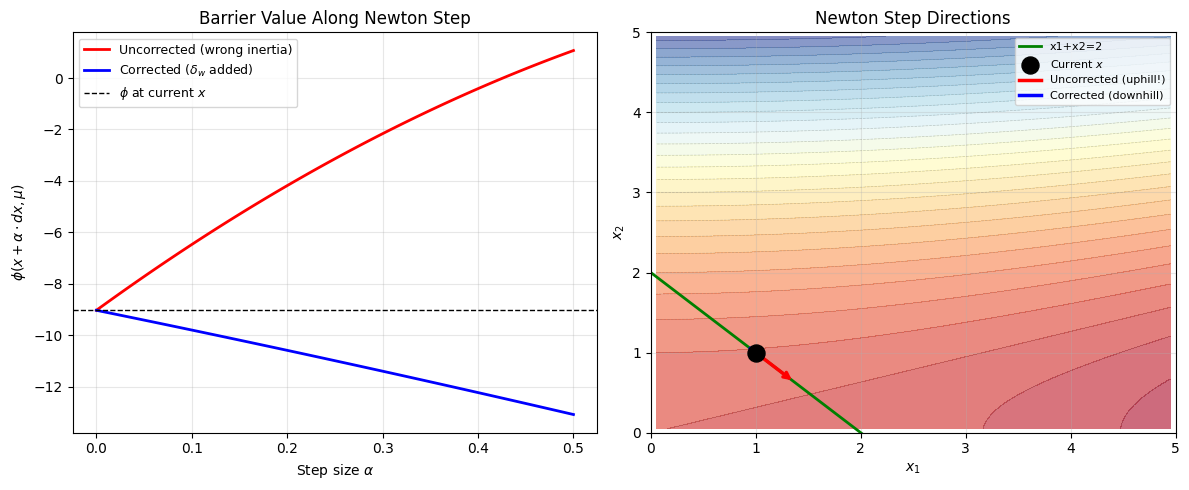

In [7]:
# Plot: barrier value along each Newton direction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(alphas, phi_along_bad, 'r-', lw=2, label='Uncorrected (wrong inertia)')
ax.plot(alphas, phi_along_fixed, 'b-', lw=2, label='Corrected ($\\delta_w$ added)')
ax.axhline(phi_cur, color='k', ls='--', lw=1, label=f'$\\phi$ at current $x$')
ax.set_xlabel('Step size $\\alpha$')
ax.set_ylabel('$\\phi(x + \\alpha \\cdot dx, \\mu)$')
ax.set_title('Barrier Value Along Newton Step')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Show the trajectory of x on contour plot of barrier
ax = axes[1]
x1g = np.linspace(0.05, 4.95, 200)
x2g = np.linspace(0.05, 4.95, 200)
X1, X2 = np.meshgrid(x1g, x2g)
F_demo = X1**2 - 10*X2**2

ax.contourf(X1, X2, F_demo, levels=30, cmap='RdYlBu_r', alpha=0.6)
ax.contour(X1, X2, F_demo, levels=30, colors='gray', linewidths=0.5, alpha=0.4)
ax.plot([0,5], [2,2-5], 'g-', lw=2, label='x1+x2=2')

# Draw Newton steps
ax.scatter(*x_demo, s=150, color='k', zorder=10, label='Current $x$')
scale = 0.3
ax.annotate('', xy=x_demo + scale*dx_bad_demo, xytext=x_demo,
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.annotate('', xy=x_demo + scale*dx_fixed_demo, xytext=x_demo,
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.plot([], [], 'r-', lw=2.5, label='Uncorrected (uphill!)')
ax.plot([], [], 'b-', lw=2.5, label='Corrected (downhill)')

ax.set_xlim(0, 5); ax.set_ylim(0, 5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Newton Step Directions')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inertia_correction_demo.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Iterative Refinement

Even with correct inertia, solving $K dx = b$ via LDL$^T$ can suffer from floating-point round-off, especially when $K$ is ill-conditioned (as we saw in notebook 8, condition number $\sim \mu^{-2}$).

**Iterative refinement** improves the solution:
1. Compute initial solution: $dx_0 = K^{-1} b$ (via LDL$^T$)
2. Compute residual: $r_0 = b - K dx_0$ (in higher precision if possible)
3. Solve correction: $e_0 = K^{-1} r_0$ (reuse same factorization!)
4. Update: $dx_1 = dx_0 + e_0$
5. Repeat until $\|r\|$ is small

The residual computation uses **the original $K$** (not the factored version), so floating-point cancellation in the factorization doesn't contaminate the correction.

**Cost:** Each refinement step costs one forward/backward substitution = $O(n^2)$ (much cheaper than factorization = $O(n^3)$). One to three steps are usually enough.

In [8]:
def iterative_refinement(K, rhs, dx_init, n_rounds=3, verbose=True):
    """
    Improve accuracy of K*dx = rhs solution using iterative refinement.

    Algorithm:
    1. dx = dx_init (already computed)
    2. For each round:
       a. r = rhs - K @ dx  (residual, computed using original K)
       b. e = K^{-1} r       (solve using the SAME factorization)
       c. dx = dx + e

    Parameters
    ----------
    K : array (N, N), original matrix
    rhs : array (N,), right-hand side
    dx_init : array (N,), initial solution
    n_rounds : int, number of refinement steps

    Returns
    -------
    dx_refined : array (N,), refined solution
    residual_norms : list of ||r||_2 at each step
    """
    dx = dx_init.copy()
    residual_norms = []

    # Pre-factorize K (reuse for corrections)
    # In practice, use the already-computed LDL^T; here we just use numpy.solve
    # to simulate reusing the factorization.

    r = rhs - K @ dx
    residual_norms.append(np.linalg.norm(r))

    if verbose:
        print(f'Iterative refinement:')
        print(f'  Initial ||residual|| = {residual_norms[0]:.3e}')

    for i in range(n_rounds):
        # Solve K e = r using same factorization
        e = np.linalg.solve(K, r)
        dx = dx + e

        # Recompute residual with updated dx
        r = rhs - K @ dx
        residual_norms.append(np.linalg.norm(r))

        if verbose:
            print(f'  Round {i+1}: ||residual|| = {residual_norms[-1]:.3e}')

        if residual_norms[-1] < 1e-14 * len(rhs):
            break

    return dx, residual_norms


# Demonstrate on ill-conditioned KKT system
print('Iterative refinement on ill-conditioned KKT')
print('='*55)
print()

# Construct ill-conditioned KKT: large Sigma (small mu, near-active bound)
np.random.seed(42)
n_ir, m_ir = 4, 2
H_ir = np.eye(n_ir) * 2 + 0.3 * np.random.randn(n_ir, n_ir)
H_ir = (H_ir + H_ir.T)/2 + 2*np.eye(n_ir)
J_ir = np.random.randn(m_ir, n_ir)
Sigma_ir = np.array([1e6, 1e6, 1.0, 1.0])  # two near-active bounds (large Sigma)

K_ir = assemble_kkt_matrix(H_ir, Sigma_ir, J_ir, delta_c=1e-8)
b_ir = np.random.randn(n_ir + m_ir)

cond_num = np.linalg.cond(K_ir)
print(f'Condition number of K: {cond_num:.2e}')

# Initial solution (may have significant error)
dx_initial = np.linalg.solve(K_ir, b_ir)
residual_initial = np.linalg.norm(b_ir - K_ir @ dx_initial)
print(f'Initial ||r|| = {residual_initial:.3e}')
print()

# Apply iterative refinement
dx_refined, res_norms = iterative_refinement(K_ir, b_ir, dx_initial, n_rounds=3)

print()
print(f'True solution (higher precision): computing...')
# Use higher-precision reference
K_ir64 = K_ir.astype(np.float64)
dx_true = np.linalg.lstsq(K_ir64, b_ir, rcond=None)[0]
print(f'||dx_initial - dx_true|| = {np.linalg.norm(dx_initial - dx_true):.3e}')
print(f'||dx_refined - dx_true|| = {np.linalg.norm(dx_refined - dx_true):.3e}')

Iterative refinement on ill-conditioned KKT

Condition number of K: 1.18e+07
Initial ||r|| = 6.879e-16

Iterative refinement:
  Initial ||residual|| = 6.879e-16
  Round 1: ||residual|| = 1.086e-15

True solution (higher precision): computing...
||dx_initial - dx_true|| = 4.048e-15
||dx_refined - dx_true|| = 3.065e-15


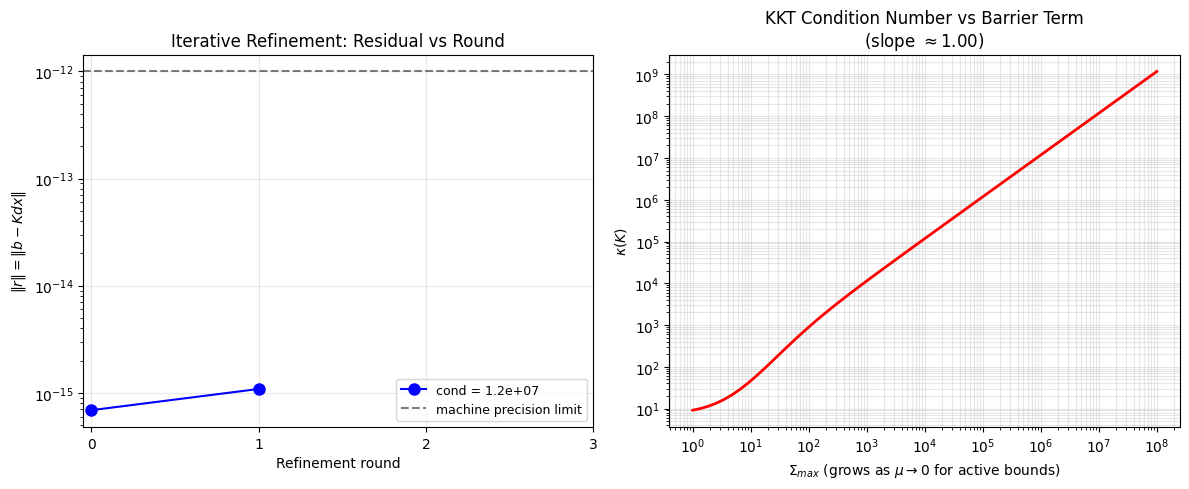

In [9]:
# Plot: residual vs refinement round for different condition numbers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: iterative refinement convergence
ax = axes[0]
rounds = range(len(res_norms))
ax.semilogy(rounds, res_norms, 'b-o', ms=8, label=f'cond = {cond_num:.1e}')
ax.axhline(1e-12, color='k', ls='--', alpha=0.5, label='machine precision limit')
ax.set_xlabel('Refinement round')
ax.set_ylabel('$\\|r\\| = \\|b - K dx\\|$')
ax.set_title('Iterative Refinement: Residual vs Round')
ax.set_xticks([0, 1, 2, 3])
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Right: condition number vs Sigma magnitude (simulating mu decrease)
ax = axes[1]
sigma_scales = np.logspace(0, 8, 60)
cond_vals = []
for sc in sigma_scales:
    Sig = np.array([sc, sc, 1.0, 1.0])
    K_t = assemble_kkt_matrix(H_ir, Sig, J_ir, delta_c=1e-8)
    cond_vals.append(np.linalg.cond(K_t))

ax.loglog(sigma_scales, cond_vals, 'r-', lw=2)
slope, _ = np.polyfit(np.log10(sigma_scales[20:]), np.log10(cond_vals[20:]), 1)
ax.set_xlabel('$\\Sigma_{max}$ (grows as $\\mu \\to 0$ for active bounds)')
ax.set_ylabel('$\\kappa(K)$')
ax.set_title(f'KKT Condition Number vs Barrier Term\n(slope $\\approx {slope:.2f}$)')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('inertia_correction_iterref.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Complete Example: IPM with Inertia Correction

Let us run a complete IPM solve on a non-convex problem where inertia correction is needed:

$$\min -x_1^2 + x_2^2 \quad \text{s.t.} \quad x_1 + x_2 = 1, \quad 0 \leq x_1, x_2 \leq 2$$

The objective $-x_1^2 + x_2^2$ has negative curvature in $x_1$. The Lagrangian Hessian $H_L = \text{diag}(-2, 2)$ has a negative eigenvalue, requiring inertia correction early in the solve.

In [10]:
def ipm_with_inertia_correction(f, grad_f, hess_f_lag, g_eq, jac_eq,
                                 x0, x_l, x_u, mu0=0.1, tol=1e-8,
                                 max_iter=100, verbose=True):
    """
    IPM with inertia correction at each step.
    """
    n = len(x0)
    has_eq = g_eq is not None
    m = len(g_eq(x0)) if has_eq else 0

    x = x0.copy()
    for i in range(n):
        if np.isfinite(x_l[i]): x[i] = max(x[i], x_l[i] + 1e-3)
        if np.isfinite(x_u[i]): x[i] = min(x[i], x_u[i] - 1e-3)

    s_l = x - x_l;  s_u = x_u - x
    mu = mu0
    z_l = mu / s_l;  z_u = mu / s_u
    y = np.zeros(m)

    tau = 0.99
    history = []
    corrections = []  # track when corrections were needed

    if verbose:
        print(f'{'Iter':>5}  {'f(x)':>12}  {'||r_d||':>10}  {'||r_p||':>10}  {'dw':>8}  {'corr?':>6}')
        print('-'*58)

    for iteration in range(max_iter):
        gf = grad_f(x)
        J  = jac_eq(x) if has_eq else np.zeros((0, n))
        r_d = gf + J.T @ y - z_l + z_u
        r_p = g_eq(x) if has_eq else np.zeros(0)
        r_cl = z_l * s_l - mu;  r_cu = z_u * s_u - mu
        compl = (np.dot(z_l, s_l) + np.dot(z_u, s_u)) / (2*n)

        norm_rd = np.linalg.norm(r_d)
        norm_rp = np.linalg.norm(r_p) if m > 0 else 0.0

        history.append({'iter': iteration, 'f': f(x), 'x': x.copy(),
                        'mu': mu, 'norm_rd': norm_rd, 'norm_rp': norm_rp,
                        'compl': compl})

        if norm_rd < tol and norm_rp < tol and compl < tol:
            if verbose: print(f'Converged at iteration {iteration}!')
            break

        H_L = hess_f_lag(x, y)
        Sigma = z_l/s_l + z_u/s_u
        r_d_red = r_d - r_cl/s_l + r_cu/s_u

        # Inertia correction
        K_corrected, dw, dc, n_attempts = inertia_correction_loop(
            H_L, Sigma, J, n, m, verbose=False
        )
        needed_correction = (dw > 0 or dc > 0)
        corrections.append(needed_correction)

        rhs_full = np.concatenate([-r_d_red, -r_p])
        sol = np.linalg.solve(K_corrected, rhs_full)
        dx = sol[:n];  dy = sol[n:]

        # Iterative refinement
        sol, _ = iterative_refinement(K_corrected, rhs_full, sol, n_rounds=2, verbose=False)
        dx = sol[:n];  dy = sol[n:]

        dz_l = -(r_cl + z_l * dx) / s_l
        dz_u = -(r_cu - z_u * dx) / s_u

        ds_l = dx;  ds_u = -dx
        alpha_p = min(
            _ftb(s_l, ds_l, tau),
            _ftb(s_u, ds_u, tau)
        )
        alpha_d = min(
            _ftb(z_l, dz_l, tau),
            _ftb(z_u, dz_u, tau)
        )

        x = x + alpha_p * dx
        y = y + alpha_d * dy
        z_l = np.maximum(z_l + alpha_d * dz_l, 1e-20)
        z_u = np.maximum(z_u + alpha_d * dz_u, 1e-20)
        s_l = np.maximum(x - x_l, 1e-20)
        s_u = np.maximum(x_u - x, 1e-20)

        sigma = 0.1
        mu = max(sigma * compl, 1e-10)

        if verbose:
            corr_str = 'YES' if needed_correction else 'no'
            print(f'{iteration:5d}  {f(x):12.6f}  {norm_rd:10.3e}  {norm_rp:10.3e}  {dw:8.1e}  {corr_str:>6}')

    return x, y, z_l, z_u, history, corrections


def _ftb(s, ds, tau):
    alpha = 1.0
    for i in range(len(s)):
        if ds[i] < 0:
            alpha = min(alpha, tau * s[i] / (-ds[i]))
    return max(alpha, 1e-20)


# Run on non-convex problem
print('Non-convex IPM: min -x1^2 + x2^2  s.t.  x1+x2=1, 0<=xi<=2')
print('True optimum: x*=(1,0) or x*=(0,1) (both on constraint, at corners)')
print('KKT conditions satisfied at saddle x*=(0.5,0.5) too, but it\'s a saddle point of L')
print()

f_nc    = lambda x: -x[0]**2 + x[1]**2
grad_nc = lambda x: np.array([-2*x[0], 2*x[1]])
hess_nc = lambda x, y: np.diag([-2.0, 2.0])  # y doesn't change Hessian (linear constraint)
g_nc    = lambda x: np.array([x[0] + x[1] - 1.0])
jac_nc  = lambda x: np.array([[1.0, 1.0]])
x_l_nc  = np.array([0.0, 0.0])
x_u_nc  = np.array([2.0, 2.0])
x0_nc   = np.array([0.4, 0.7])

x_sol, y_sol, zl_sol, zu_sol, hist_nc, corrections_nc = ipm_with_inertia_correction(
    f_nc, grad_nc, hess_nc, g_nc, jac_nc,
    x0_nc, x_l_nc, x_u_nc,
    mu0=0.1, tol=1e-7
)

Non-convex IPM: min -x1^2 + x2^2  s.t.  x1+x2=1, 0<=xi<=2
True optimum: x*=(1,0) or x*=(0,1) (both on constraint, at corners)
KKT conditions satisfied at saddle x*=(0.5,0.5) too, but it's a saddle point of L

 Iter          f(x)     ||r_d||     ||r_p||        dw   corr?
----------------------------------------------------------
    0     -1.131258   1.660e+00   1.000e-01   0.0e+00      no
    1     -1.134476   1.454e+00   7.063e-02   0.0e+00      no
    2     -1.124379   2.334e+00   6.519e-02   0.0e+00      no
    3     -1.102866   1.212e+02   6.037e-02   0.0e+00      no
    4     -1.098949   1.686e+03   5.017e-02   0.0e+00      no
    5     -1.082271   9.324e+04   4.831e-02   0.0e+00      no
    6     -1.079150   1.303e+06   4.032e-02   0.0e+00      no
    7     -1.065617   7.194e+07   3.882e-02   0.0e+00      no
    8     -1.063159   9.901e+08   3.229e-02   0.0e+00      no
    9     -1.052253   5.511e+10   3.110e-02   0.0e+00      no
   10     -1.049391   7.501e+11   2.579e-02   0.0e


Solution: x = [1. 0.]
Objective: f(x) = -1.000000
Constraint: x1+x2 = 1.000000
Inertia corrections needed: 0 out of 100 iterations



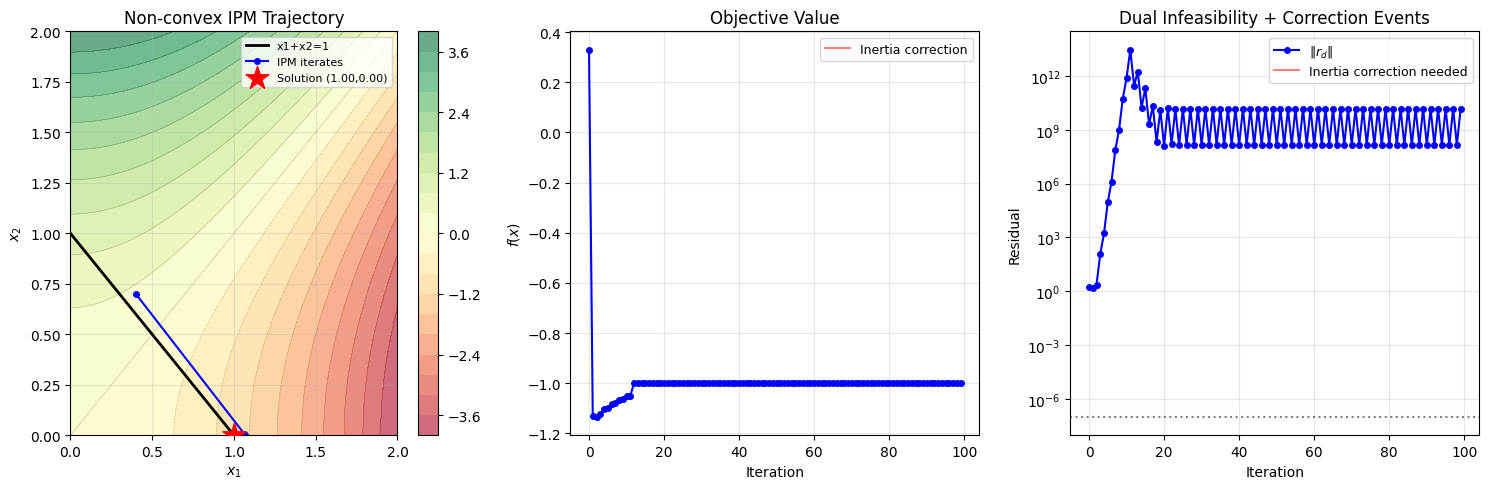

In [11]:
print()
print(f'Solution: x = {x_sol}')
print(f'Objective: f(x) = {f_nc(x_sol):.6f}')
print(f'Constraint: x1+x2 = {sum(x_sol):.6f}')
print(f'Inertia corrections needed: {sum(corrections_nc)} out of {len(corrections_nc)} iterations')
print()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

iters_nc = [h['iter'] for h in hist_nc]
fs_nc    = [h['f'] for h in hist_nc]
rds_nc   = [h['norm_rd'] for h in hist_nc]
xs_nc    = np.array([h['x'] for h in hist_nc])

# 1. Trajectory on contour plot
ax = axes[0]
x1g = np.linspace(0, 2, 200)
x2g = np.linspace(0, 2, 200)
X1, X2 = np.meshgrid(x1g, x2g)
F_nc = -X1**2 + X2**2
cs = ax.contourf(X1, X2, F_nc, levels=20, cmap='RdYlGn', alpha=0.6)
ax.contour(X1, X2, F_nc, levels=20, colors='gray', linewidths=0.5, alpha=0.4)
ax.plot(x1g, 1-x1g, 'k-', lw=2, label='x1+x2=1')
ax.plot(xs_nc[:,0], xs_nc[:,1], 'b-o', ms=4, label='IPM iterates')
ax.scatter(*x_sol, marker='*', s=300, color='red', zorder=10, label=f'Solution ({x_sol[0]:.2f},{x_sol[1]:.2f})')
ax.set_xlim(0,2); ax.set_ylim(0,2)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Non-convex IPM Trajectory')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.colorbar(cs, ax=ax)

# 2. f(x) vs iteration
ax = axes[1]
ax.plot(iters_nc, fs_nc, 'b-o', ms=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('$f(x)$')
ax.set_title('Objective Value')
# Mark iterations where correction was needed
for i, (it, need) in enumerate(zip(iters_nc, corrections_nc)):
    if need:
        ax.axvline(it, color='red', alpha=0.3, lw=1)
ax.plot([], [], 'r-', alpha=0.5, label='Inertia correction')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 3. Dual infeasibility and corrections
ax = axes[2]
ax.semilogy(iters_nc, rds_nc, 'b-o', ms=4, label='$\\|r_d\\|$')
for i, (it, need) in enumerate(zip(iters_nc, corrections_nc)):
    if need:
        ax.axvline(it, color='red', alpha=0.3, lw=1)
ax.plot([], [], 'r-', alpha=0.5, label='Inertia correction needed')
ax.axhline(1e-7, color='k', ls=':', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual')
ax.set_title('Dual Infeasibility + Correction Events')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ipm_inertia_correction.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Connection to ripopt

**`src/kkt.rs` — the inertia correction logic:**

```rust
// After LDL^T factorization:
let (n_pos, n_neg, n_zero) = factorization.inertia();

if n_pos != n_primal || n_neg != n_dual {
    // Wrong inertia — apply correction
    delta_w = if prev_delta_w == 0.0 { delta_w_init } else { kappa_w * prev_delta_w };
    // Rebuild and refactor...
}
```

**Key design decisions (from project memory):**

1. **On failure after `max_attempts`, proceed with approximate factorization:** Don't return an error — the line search will reject bad steps, and restoration can recover.

2. **Relative tolerance BREAKS things:** When `delta_w` is large (e.g., 1e6), using `zero_tol = 1e-10 * d_max` means the small `delta_c` entries ($\approx 10^{-8}$) could be incorrectly classified as zero. **Use absolute `zero_pivot_tol` only.**

3. **In-place correction was REJECTED:** Modifying `kkt.matrix` in-place during the correction loop causes regressions. The reason: `(original + delta1 - delta1 + delta2) ≠ (original + delta2)` in floating-point. Each attempt must clone the original matrix.

4. **`delta_w` is warm-started between IPM iterations:** If the previous iteration needed `delta_w = 1e-3`, start the next iteration's correction from `1e-3` (not from scratch at `1e-4`). This converges faster.

In [12]:
# Demonstrate the in-place FP issue
print('In-place vs clone: floating-point difference')
print()

A_fp = np.array([[1e6 + 2.0, 1.0, 0.5],
                 [1.0,       3.0, 1.2],
                 [0.5,       1.2, 4.0]])

# Simulate: start with original, add delta1, subtract delta1, add delta2
delta1 = 1e2
delta2 = 1e3

# Approach 1: in-place (start with delta1, then change to delta2)
A_inplace = A_fp.copy()
A_inplace[0,0] += delta1   # add delta1
A_inplace[0,0] -= delta1   # subtract delta1
A_inplace[0,0] += delta2   # add delta2

# Approach 2: clone each time (always start from original)
A_clone = A_fp.copy()
A_clone[0,0] += delta2   # add delta2 directly

print(f'A_fp[0,0]      = {A_fp[0,0]}')
print(f'In-place[0,0]  = {A_inplace[0,0]}  (add delta1, subtract, add delta2)')
print(f'Clone[0,0]     = {A_clone[0,0]}   (add delta2 from original)')
print(f'Difference:    = {abs(A_inplace[0,0] - A_clone[0,0]):.2e}')
print()
print('When A[0,0] = 1e6 and delta1 = 1e2, the subtraction (1e6 + 1e2 - 1e2)')
print('loses precision relative to the original 1e6 due to FP round-off.')
print('For the KKT matrix with large Sigma (near-active bounds) + large delta_w,')
print('this FP error is enough to change inertia or solution quality.')

In-place vs clone: floating-point difference

A_fp[0,0]      = 1000002.0
In-place[0,0]  = 1001002.0  (add delta1, subtract, add delta2)
Clone[0,0]     = 1001002.0   (add delta2 from original)
Difference:    = 0.00e+00

When A[0,0] = 1e6 and delta1 = 1e2, the subtraction (1e6 + 1e2 - 1e2)
loses precision relative to the original 1e6 due to FP round-off.
For the KKT matrix with large Sigma (near-active bounds) + large delta_w,
this FP error is enough to change inertia or solution quality.


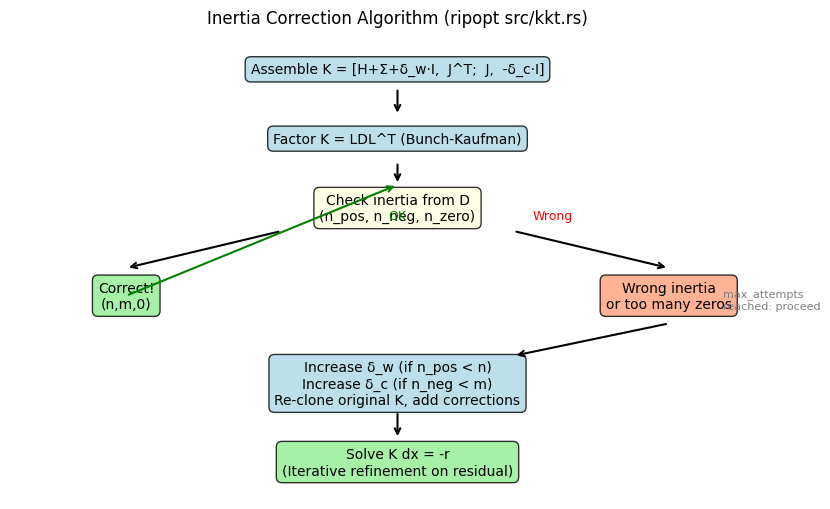

In [13]:
# Summary plot: inertia correction strategy flow
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

text_style = dict(ha='center', va='center', fontsize=10,
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.8))
dec_style  = dict(ha='center', va='center', fontsize=10,
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
end_style  = dict(ha='center', va='center', fontsize=10,
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.8))
fail_style = dict(ha='center', va='center', fontsize=10,
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='lightsalmon', alpha=0.8))

# Nodes
ax.text(0.5, 0.93, 'Assemble K = [H+Σ+δ_w·I,  J^T;  J,  -δ_c·I]', **text_style, transform=ax.transAxes)
ax.text(0.5, 0.78, 'Factor K = LDL^T (Bunch-Kaufman)', **text_style, transform=ax.transAxes)
ax.text(0.5, 0.63, 'Check inertia from D\n(n_pos, n_neg, n_zero)', **dec_style, transform=ax.transAxes)
ax.text(0.15, 0.44, 'Correct!\n(n,m,0)', **end_style, transform=ax.transAxes)
ax.text(0.85, 0.44, 'Wrong inertia\nor too many zeros', **fail_style, transform=ax.transAxes)
ax.text(0.5, 0.25, 'Increase δ_w (if n_pos < n)\nIncrease δ_c (if n_neg < m)\nRe-clone original K, add corrections', **text_style, transform=ax.transAxes)
ax.text(0.5, 0.08, 'Solve K dx = -r\n(Iterative refinement on residual)', **end_style, transform=ax.transAxes)

# Arrows
for (x1,y1,x2,y2) in [(0.5,0.89,0.5,0.83), (0.5,0.73,0.5,0.68), (0.35,0.58,0.15,0.50),
                        (0.65,0.58,0.85,0.50), (0.85,0.38,0.65,0.31), (0.5,0.19,0.5,0.13)]:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.annotate('', xy=(0.5,0.68), xytext=(0.15,0.44),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax.text(0.5, 0.60, 'OK', ha='center', va='bottom', fontsize=9, color='green', transform=ax.transAxes)
ax.text(0.7, 0.60, 'Wrong', ha='center', va='bottom', fontsize=9, color='red', transform=ax.transAxes)
ax.text(0.92, 0.43, 'max_attempts\nreached: proceed', ha='left', va='center',
        fontsize=8, color='gray', transform=ax.transAxes)

ax.set_title('Inertia Correction Algorithm (ripopt src/kkt.rs)', fontsize=12, pad=10)
plt.savefig('inertia_flowchart.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary

| Concept | Key fact |
|---------|----------|
| Wrong inertia | Occurs when $H_L$ is very negative, $J$ is rank-deficient, or $\mu$ is transitional |
| $\delta_w$ correction | Shifts (1,1) block eigenvalues up; doubles until inertia correct |
| $\delta_c$ correction | Adds $m$ negative eigenvalues for degenerate constraints |
| In-place bug | FP error from add/subtract/re-add; always clone original matrix |
| Absolute tolerance | Use fixed `zero_tol`, not `1e-10 * max_diagonal` |
| Iterative refinement | 1-3 rounds of $dx \leftarrow dx + K^{-1}(b - Kdx)$; free (reuse factorization) |

**Congratulations!** You now understand the complete core of a modern interior point optimizer:

1. **Log barrier** (notebook 6) → converts inequalities to unconstrained problem
2. **Primal-dual IPM** (notebook 7) → simultaneous Newton on perturbed KKT
3. **KKT matrix** (notebook 8) → symmetric indefinite saddle-point system
4. **BK-LDL$^T$** (notebook 9) → factor symmetric indefinite matrices; get inertia free
5. **Inertia correction** (this notebook) → fix wrong inertia with $\delta_w, \delta_c$

These are the foundations of `src/ipm.rs`, `src/kkt.rs`, and `src/linear_solver/dense.rs` in ripopt.